# Step 3 — Signal EDA: Intraday Conditional Strategy (QQQ)

**Pure EDA.** No strategy module, no backtester, no orders. This notebook is the narrative
render of `eda.py` (the reproducible workhorse — run `python -m research.killed.intraday_conditional.eda`).
All logic lives in `eda.py`; the notebook imports it so the two can never drift.

**Spec:** `research/research_notes/intraday_conditional_strategy_notes.md` (Step 3).

## Sample discipline (enforced in code)
- **IS window = 2015-01-01 .. 2021-12-31** — the *only* evaluated sample.
- **2014 = warm-up only**: it populates trailing ATR / overnight-gap for early-2015 days, then
  drops out of every statistic, plot, and bucket via the IS date mask.
- **OOS (2022+) is never loaded** — the SQL query is bounded `bar_datetime < '2022-01-01'`, and a
  runtime assertion re-checks it. If a cell read post-2021 data, it would be a bug.
- **Half-days (1pm ET close) and IBKR-gap days** from `half_days.json` are dropped, not imputed.

## Bar-edge convention (committed)
IBKR 5-min bars are **START-labeled** and stored in US/Central; `eda.py` converts to US/Eastern.
"close at time *T*" = close of the bar **ending** at *T* = close of the *(T−5min)* labeled bar
(matching the spec's "close at 10:30 = close of the 10:25 bar"):

| symbol | definition |
|---|---|
| `open_0930` | open of the 09:30 ET bar (session open) |
| `close_1030` | close of the **10:25** ET bar (= "close at 10:30") |
| `close_1555` | close of the **15:50** ET bar (= "close at 15:55"; ≈ open of 15:55 bar = the flat-into-close exit fill) |
| `session_close` | close of the 15:55 ET bar (true 16:00 close; used only for the *next* day's gap) |

## Feature definitions (committed)
- `r_1h  = close_1030 / open_0930 − 1`  (first 60 min: 09:30 → 10:25)
- `r_30 / r_90` — same, ending at the 09:55 / 10:55 bar close (30/90-min robustness)
- `r_rod = close_1555 / close_1030 − 1`  (rest of day: 10:25 → 15:50)
- `overnight_gap = open_0930 / prior_session_close − 1`
- `ATR_pit` — **point-in-time** trailing-20-day mean of daily `(high−low)/open`, over the 20 valid
  days **strictly before** day *t* (`shift(1).rolling(20)`); no same-day, no future.
- `m = |r_1h| / ATR_pit`  (vol-normalized magnitude)
- `signed_rod = sign(r_1h) · r_rod`  (>0 continuation, <0 fade)

## Pre-commit declarations (written BEFORE running the cross-tab)
- **Bucket scheme: SEXTILES of `m`, edges fixed once** at the 1/6..5/6 quantiles of the IS
  `m`-distribution. We do **not** search for a flip threshold that maximizes separation. Each
  window (30/60/90) gets its own sextile edges from its own `m`.
- **This is exploratory.** Six buckets × seven years × three windows means *some* t-stats will look
  significant by chance. We read the **sign pattern and its stability**, not isolated t-stats, and
  we do not cherry-pick.

In [1]:
import sys, os
# Make the repo root importable when the notebook runs from this directory.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import pandas as pd
from IPython.display import Image, display
from research.killed.intraday_conditional import eda

PLOTS = eda.PLOTS_DIR
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

## Load + build features (IS only, OOS never touched)

In [2]:
bars = eda.load_bars_et()
feat_all = eda.build_daily_features(bars)
feat = eda.is_slice(feat_all)
excluded = eda._load_excluded_days()

print(f'Loaded bars: {len(bars):,}  ({bars.index.min().date()} .. {bars.index.max().date()})')
assert bars.index.max().tz_localize(None) < pd.Timestamp(eda.OOS_FLOOR), 'OOS leak!'
print(f'Valid IS trading days: {len(feat)}  ({feat.index.min().date()} .. {feat.index.max().date()})')
print(f'Excluded days (half/gap) from half_days.json: {len(excluded)}')

ref_price = feat['close_1030'].mean()
cost = eda.cost_floor_bps(ref_price)
print(f"\nCost floor (Step-4 assumptions, ${eda.REF_NOTIONAL:,.0f} notional, ref ${ref_price:.0f}): "
      f"{cost['slippage_rt_bps']:.2f} slippage + {cost['commission_rt_bps']:.2f} commission "
      f"= {cost['total_rt_bps']:.2f} bps round-trip")

Loaded bars: 137,594  (2014-01-02 .. 2021-12-31)
Valid IS trading days: 1733  (2015-01-21 .. 2021-12-31)
Excluded days (half/gap) from half_days.json: 28

Cost floor (Step-4 assumptions, $50,000 notional, ref $189): 1.00 slippage + 0.37 commission = 1.37 bps round-trip


## (1) Intraday volatility profile — U-shape, and how elevated is 10:30 vs midday?

09:30 open bar 19.1 bps | 10:25 (end-1h) 11.5 bps | 12:00 midday 9.4 bps
ratio 10:25/midday = 1.22x ; open/midday = 2.02x


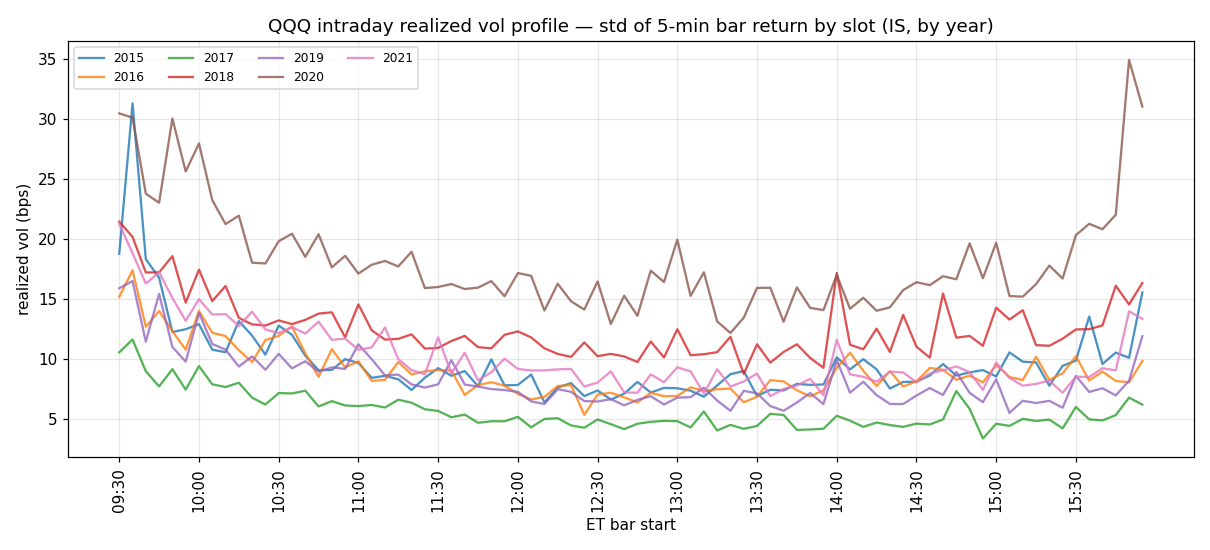

In [3]:
prof = eda.vol_profile(bars, excluded)
vp = eda.plot_vol_profile(prof, PLOTS / '01_vol_profile.png')
print(f"09:30 open bar {vp['open_bps']:.1f} bps | 10:25 (end-1h) {vp['bar_1025_bps']:.1f} bps | "
      f"12:00 midday {vp['midday_1200_bps']:.1f} bps")
print(f"ratio 10:25/midday = {vp['ratio_1025_midday']:.2f}x ; open/midday = {vp['ratio_open_midday']:.2f}x")
display(Image(str(PLOTS / '01_vol_profile.png')))

The classic U-shape holds every year: the 09:30 bar runs ~2× midday vol; the 10:25 bar (where the
first-hour signal lands and the trade would enter) is still ~1.2× midday. So a 10:30 entry sits on
the *shoulder* of the U, not the trough — consistent with the Step-6 note that spreads/impact at
10:30 are non-trivially worse than at noon.

## (2) First-hour return distribution vs overnight gap

r_1h: mean 2.12 bps, std 52.6 bps, ann vol 8.3%
overnight gap: std 85.2 bps, ann vol 13.5%


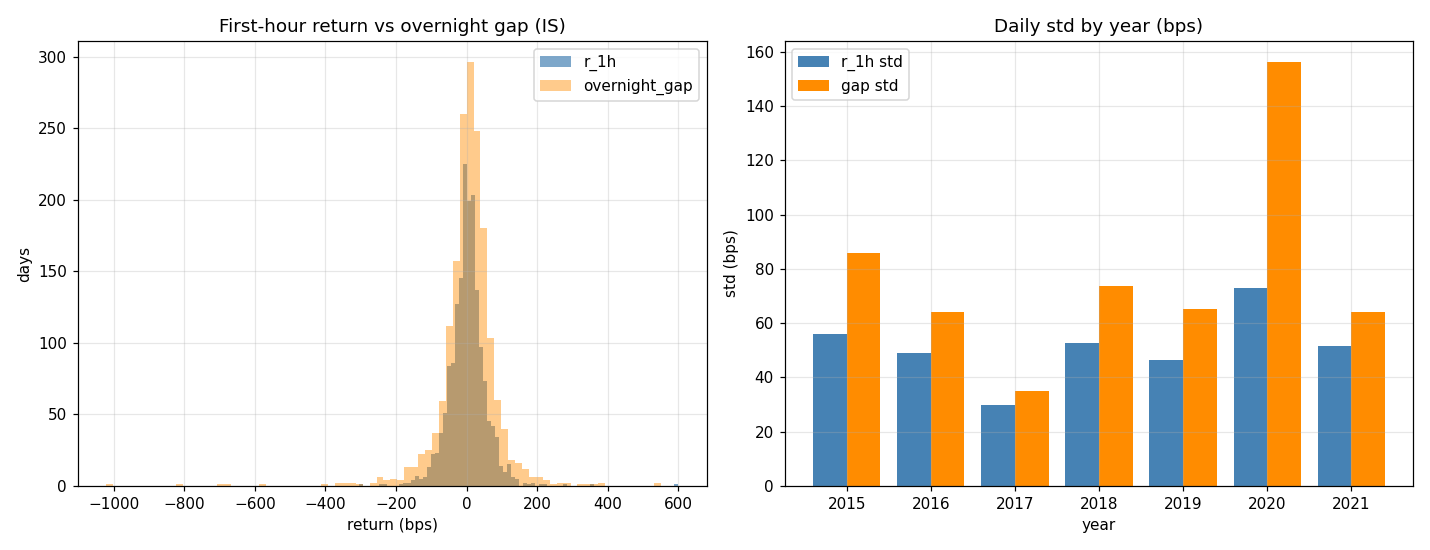

In [4]:
rd = eda.plot_r1h_distribution(feat, PLOTS / '02_r1h_distribution.png')
print(f"r_1h: mean {rd['r1h_mean_bps']:.2f} bps, std {rd['r1h_std_bps']:.1f} bps, ann vol {rd['r1h_ann_vol']:.1%}")
print(f"overnight gap: std {rd['gap_std_bps']:.1f} bps, ann vol {rd['gap_ann_vol']:.1%}")
display(Image(str(PLOTS / '02_r1h_distribution.png')))

First-hour moves (ann vol ~8%) are materially *smaller* than overnight gaps (~13%). That ordering
matters for output (4): the overnight gap is the larger driver, so any first-hour "signal" must be
shown to survive controlling for the gap.

## (3) THE conditional cross-tab — key test of H1
Mean **and** median signed `r_rod` (bps), with SE, t-stat, and n per `m`-sextile, plus the
round-trip cost-floor band. H1 predicts a monotone climb: small `m` → fade (negative), large `m` →
continue (positive).

sextile edges (fixed once on IS): 0.064, 0.134, 0.216, 0.325, 0.510


,n,mean_bps,median_bps,se_bps,t_stat,m_lo,m_hi
bucket,,,,,,,
1,289,-6.22,-0.71,4.85,-1.28,0.00,0.06
2,289,4.45,7.30,4.61,0.97,0.06,0.13
3,289,-2.29,-1.26,4.90,-0.47,0.13,0.22
4,288,-3.76,-2.75,4.60,-0.82,0.22,0.32
5,289,-1.99,0.00,5.16,-0.39,0.32,0.51
6,289,5.44,10.09,5.05,1.08,0.51,4.38



Buckets with |t|>2 (distinguishable from zero at all): NONE
Buckets whose NET edge clears the 1.37 bps floor by >2 SE AND |t|>2 (tradeable): NONE


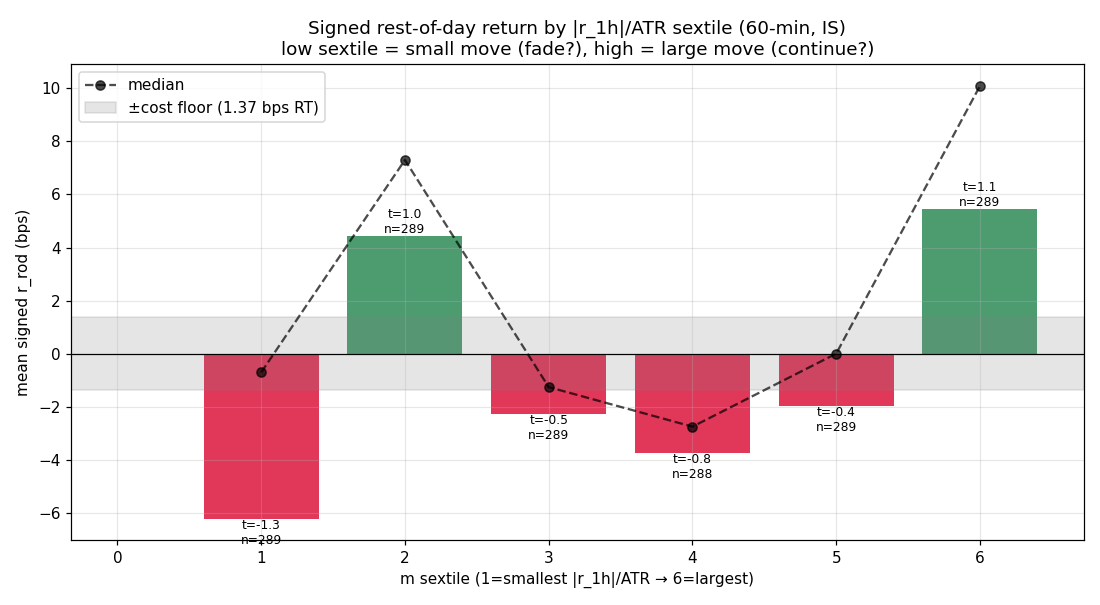

In [5]:
table60, edges60 = eda.crosstab(feat, 60)
print('sextile edges (fixed once on IS):', ', '.join(f'{e:.3f}' for e in edges60))
eda.plot_crosstab(table60, cost, PLOTS / '03_conditional_crosstab.png')
display(table60.round(2))

floor = cost['total_rt_bps']
real = table60[(table60['mean_bps'].abs() - floor > 2*table60['se_bps']) & (table60['t_stat'].abs() > 2.0)]
print(f"\nBuckets with |t|>2 (distinguishable from zero at all): "
      f"{list(table60[table60['t_stat'].abs()>2].index.astype(int)) or 'NONE'}")
print(f"Buckets whose NET edge clears the {floor:.2f} bps floor by >2 SE AND |t|>2 (tradeable): "
      f"{list(real.index.astype(int)) or 'NONE'}")
display(Image(str(PLOTS / '03_conditional_crosstab.png')))

**Read.** The pattern is a **non-monotonic zigzag** (−, +, −, −, −, +), not the predicted monotone
climb. The two tails *happen* to have the H1-consistent signs (sextile 1 fades, sextile 6
continues), but **every |t-stat| < 1.3** and each per-bucket SE (~5 bps) is as large as the nominal
edge itself. **No bucket is statistically distinguishable from zero**, so comparing the means to the
~1.4 bps cost floor is moot — the "|mean| > floor" line is an artifact of sampling noise, not an
edge. The annualized-scale figures in `eda.main()` are printed for scale only and are *not* a claim
of edge.

## (4) Overnight-gap disentangling
Re-run the cross-tab additionally conditioned on gap **sign** and **size** (median |gap| split). The
classic failure mode is mistaking gap momentum for a first-hour-continuation edge.

median |overnight gap| = 34.5 bps


gap_grp,dn_large,dn_small,up_large,up_small
bucket,,,,
1,-25.50,2.80,4.30,-13.70
2,8.00,12.00,1.80,-2.30
3,-5.50,-13.90,5.90,-0.20
4,5.40,-0.50,1.90,-18.30
5,-15.40,3.80,5.00,-1.60
6,16.30,-5.70,8.50,-1.80


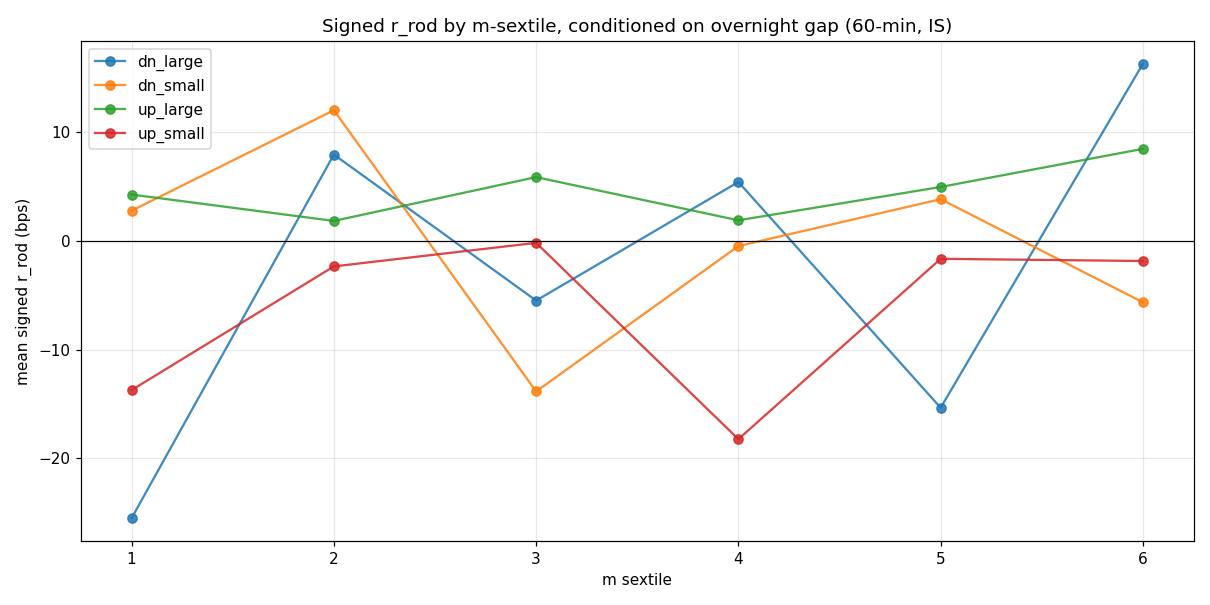

In [6]:
gap_tab, med_abs_gap = eda.gap_conditioned_crosstab(feat, edges60)
eda.plot_gap_conditioning(gap_tab, PLOTS / '04_gap_conditioning.png')
print(f'median |overnight gap| = {med_abs_gap*1e4:.1f} bps')
display(gap_tab.pivot(index='bucket', columns='gap_grp', values='mean_bps').round(1))
display(Image(str(PLOTS / '04_gap_conditioning.png')))

**Read.** No coherent structure survives the split. The only mildly suggestive cell — sextile 6
"continuation" — is concentrated in the **large-gap** subsets (`dn_large`, `up_large` positive) while
the small-gap subsets are flat-to-negative. That is the signature of **gap momentum**, not a pure
first-hour-continuation edge: exactly the conflation the notes warn against.

## (5) Regime dependence — year by year
Same fixed edges, mean signed `r_rod` per (year × sextile). Read the **stability of the sign
pattern** across years (samples are thin year-by-year), not per-cell significance.

bucket,1,2,3,4,5,6
year,,,,,,
2015,-2.00,10.30,-8.70,-25.70,3.10,2.10
2016,-5.00,-3.30,9.50,-13.80,-7.80,5.40
2017,-0.50,-3.10,-1.10,12.00,-7.50,4.00
2018,-12.90,-0.50,-40.20,-8.10,13.50,16.80
2019,-1.50,4.00,1.50,4.40,2.70,-5.30
2020,-4.90,7.70,15.00,-4.50,-30.30,10.70
2021,-17.10,21.00,-1.80,2.80,9.60,3.60


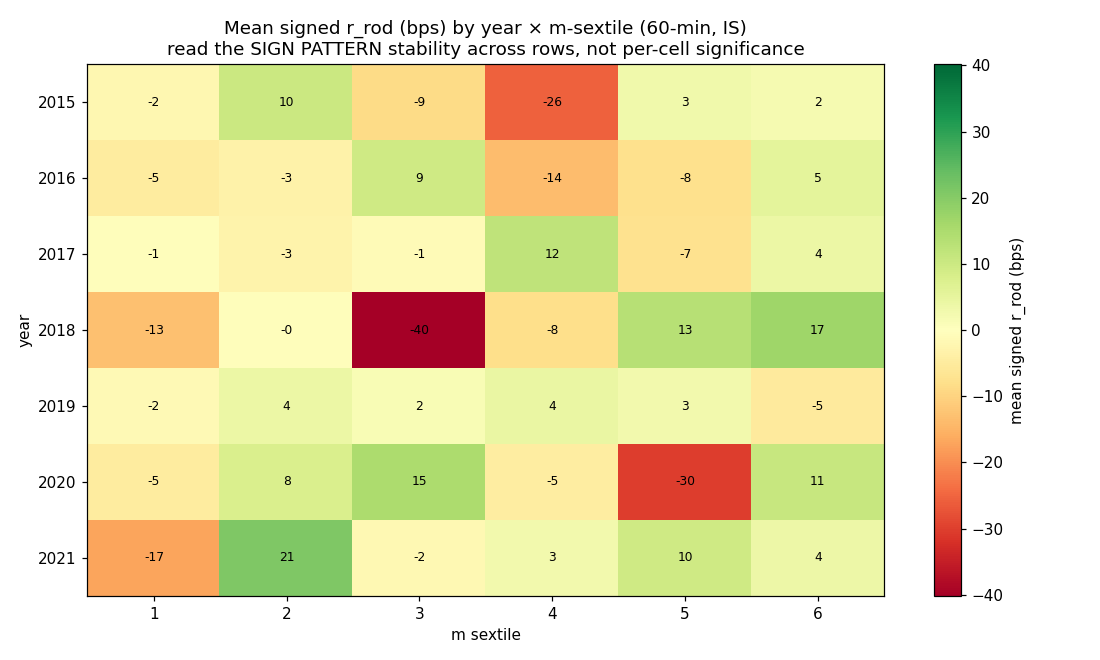

In [7]:
ytab = eda.yearly_crosstab(feat, edges60)
eda.plot_regime(ytab, PLOTS / '05_regime_by_year.png')
display(ytab.round(1))
display(Image(str(PLOTS / '05_regime_by_year.png')))

**Read.** Only sextile 1 (consistently mildly negative) and sextile 6 (positive in 6 of 7 years,
but flips negative in **2019**) show even weak sign-persistence, and both are tiny relative to noise.
The middle sextiles flip sign chaotically (e.g. sextile 3: −8.7 → +9.5 → −1.1 → **−40.2 (2018)** →
+1.5 → +15.0 → −1.8). No coherent regime; 2018 and 2020 in particular scramble the middle.

## (6) Window-length robustness — 30 / 60 / 90-min
If 60 is special but 30/90 show nothing (or the opposite), the 60-min result is suspect.

,30min,60min,90min
sextile,,,
1,3.13,-6.22,1.39
2,1.29,4.45,7.45
3,4.20,-2.29,-0.87
4,5.38,-3.76,-5.38
5,6.41,-1.99,4.22
6,-2.90,5.44,-4.24


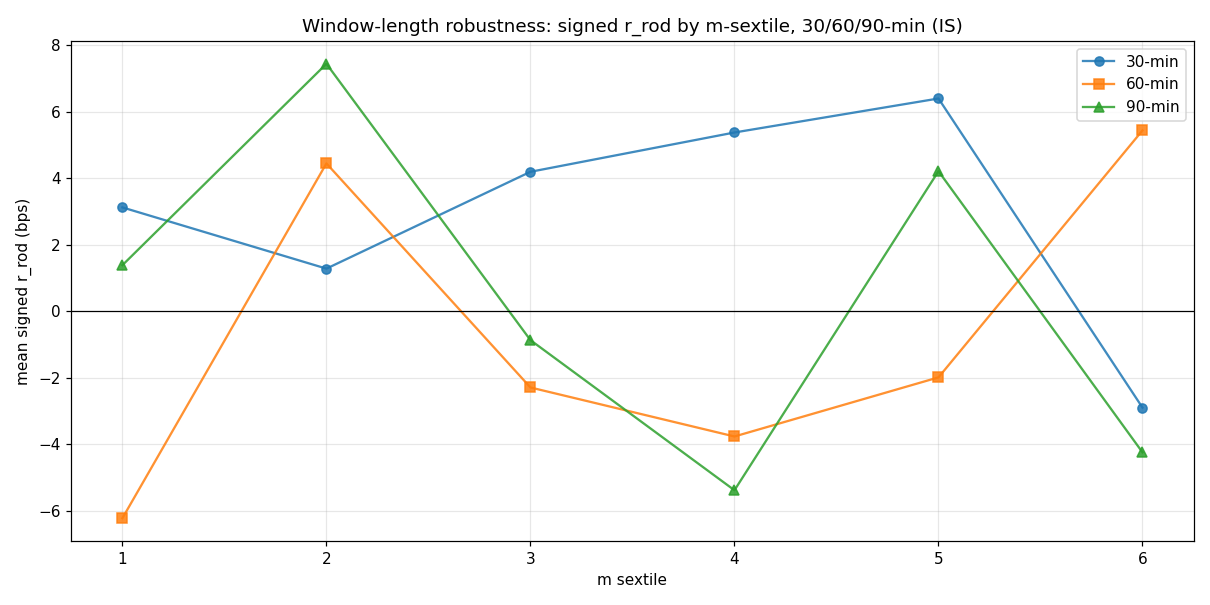

In [8]:
wtables = eda.plot_window_robustness(feat, PLOTS / '06_window_robustness.png')
summary = pd.DataFrame({f'{w}min': wtables[w]['mean_bps'] for w in (30, 60, 90)})
summary.index.name = 'sextile'
display(summary.round(2))
display(Image(str(PLOTS / '06_window_robustness.png')))

**Read — decisive.** The three windows trace **different, partly inverted** shapes. The 60-min tail
signs (sextile 1 ≈ −6, sextile 6 ≈ +5) **flip** at both 30-min (sextile 1 ≈ +3, sextile 6 ≈ −3) and
90-min (sextile 1 ≈ +1, sextile 6 ≈ −4). The "fade small / continue large" tail pattern exists
*only* at 60 min and reverses in the neighbouring windows — the notes' explicit "60 is special" red
flag. A real microstructure effect would not vanish and invert between 30 and 90 minutes.

## Verdict — STOP at Step 3

The Step-3 decision rule says proceed to Step 4 **only if** the conditional sign structure is (a)
present and monotonic-ish, (b) survives the cost floor in the tails, (c) is not explained away by
the gap conditioning, and (d) holds across most years **and** the 30/90 windows. It fails on every
one:

| Gate | Result |
|---|---|
| Monotonic conditional structure (3) | **FAIL** — non-monotonic zigzag; all \|t\| < 1.3; per-bucket SE ≈ the edge |
| Survives cost floor in tails (3) | **FAIL** — no bucket distinguishable from zero, so the floor comparison is moot |
| Not gap momentum (4) | **FAIL** — the only suggestive tail effect concentrates in large-gap days |
| Stable across years (5) | **FAIL** — only weak tail-sign persistence (sextile 6 flips in 2019); chaotic middle |
| Holds at 30/90-min (6) | **FAIL (decisive)** — tail signs invert at both neighbouring windows |

**H1 is not supported in-sample. STOP.** Per the notes' anti-pattern guidance we do **not** search
further, do **not** re-bucket, and do **not** pivot the hypothesis. OOS (2022–2025) remains
untouched and is **not** to be opened for this idea. The verdict is recorded in
`research/research_notes/intraday_conditional_strategy_notes.md` (Step 3).